In [25]:

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)


In [26]:

PROJECT_ROOT = Path("..").resolve()
DATA_MASTER_CSV = PROJECT_ROOT / "data" / "data_master.csv"
MODEL_OUT = Path("angular_predictor.keras")
PREPROCESS_OUT = Path("angular_predictor_preprocessing.json")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 30
VAL_SPLIT = 0.1
TEST_SPLIT = 0.1
AUTOTUNE = tf.data.AUTOTUNE

assert DATA_MASTER_CSV.exists(), DATA_MASTER_CSV


In [27]:

def normalize_rows(v: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    n = np.linalg.norm(v, axis=1, keepdims=True)
    return v / np.clip(n, eps, None)


def add_camera_space_targets(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    cam_pos = out[["cam_pos_x", "cam_pos_y", "cam_pos_z"]].to_numpy(dtype=np.float32)
    cam_right = normalize_rows(out[["cam_right_x", "cam_right_y", "cam_right_z"]].to_numpy(dtype=np.float32))
    cam_up = normalize_rows(out[["cam_up_x", "cam_up_y", "cam_up_z"]].to_numpy(dtype=np.float32))
    cam_forward = normalize_rows(out[["cam_forward_x", "cam_forward_y", "cam_forward_z"]].to_numpy(dtype=np.float32))
    cam_back = -cam_forward

    light_pos = out[["light0_pos_x", "light0_pos_y", "light0_pos_z"]].to_numpy(dtype=np.float32)
    light_dir = normalize_rows(out[["light0_dir_x", "light0_dir_y", "light0_dir_z"]].to_numpy(dtype=np.float32))
    rel = light_pos - cam_pos

    out["light0_pos_cam_x"] = np.einsum("ij,ij->i", rel, cam_right)
    out["light0_pos_cam_y"] = np.einsum("ij,ij->i", rel, cam_up)
    out["light0_pos_cam_z"] = np.einsum("ij,ij->i", rel, cam_back)

    out["light0_dir_cam_x"] = np.einsum("ij,ij->i", light_dir, cam_right)
    out["light0_dir_cam_y"] = np.einsum("ij,ij->i", light_dir, cam_up)
    out["light0_dir_cam_z"] = np.einsum("ij,ij->i", light_dir, cam_back)

    return out


def load_image(path: str) -> np.ndarray:
    with Image.open(path) as img:
        img = img.convert("RGB").resize(IMG_SIZE, Image.BILINEAR)
        return np.asarray(img, dtype=np.float32) / 255.0


In [28]:
df = pd.read_csv(DATA_MASTER_CSV, low_memory=False)

required_cols = [
    "num_active_lights",
    "light0_type",
    "cam_pos_x", "cam_pos_y", "cam_pos_z",
    "cam_right_x", "cam_right_y", "cam_right_z",
    "cam_up_x", "cam_up_y", "cam_up_z",
    "cam_forward_x", "cam_forward_y", "cam_forward_z",
    "light0_energy",
    "light0_color_r", "light0_color_g", "light0_color_b",
    "light0_spot_cone_deg",
    "light0_pos_x", "light0_pos_y", "light0_pos_z",
    "light0_dir_x", "light0_dir_y", "light0_dir_z",
]


def resolve_existing_image(row: pd.Series) -> str | None:
    for key in ["resolved_image_relpath", "image_relpath"]:
        raw = row.get(key)
        if pd.isna(raw):
            continue

        p = Path(str(raw))
        candidates = []
        if p.is_absolute():
            candidates.append(p)
        else:
            candidates.extend([
                PROJECT_ROOT / p,
                PROJECT_ROOT / "data" / "render-lighting" / p,
                PROJECT_ROOT / "data" / "inverse_rendering_dataset" / p,
                PROJECT_ROOT / "data" / "inverse_rendering_dataset" / "images" / p,
                PROJECT_ROOT / "data" / "spotlight-sphere-data" / p,
            ])

        for candidate in candidates:
            if candidate.exists():
                return str(candidate)

    return None


usable = df.copy()
usable["image_path"] = usable.apply(resolve_existing_image, axis=1)
usable = usable[usable["image_path"].notna()]
usable = usable[usable["num_active_lights"].fillna(0).astype(int) == 1]
for col in required_cols:
    usable = usable[usable[col].notna()]

usable = usable.reset_index(drop=True)
usable = add_camera_space_targets(usable)
usable["light_type_label"] = usable["light0_type"].astype(str).str.upper()

print("Usable rows:", len(usable))
print(usable.groupby(["dataset_source", "light_type_label"]).size())


Usable rows: 6777
dataset_source             light_type_label
inverse_rendering_dataset  SPOT                1473
render-lighting            SPOT                5304
dtype: int64


In [29]:

feature_cols = [
    "num_active_lights",
    "cam_pos_x", "cam_pos_y", "cam_pos_z",
    "light0_energy",
    "light0_color_r", "light0_color_g", "light0_color_b",
    "light0_spot_cone_deg",
]
cat_cols = ["light_type_label"]
target_cols = [
    "light0_pos_cam_x", "light0_pos_cam_y", "light0_pos_cam_z",
    "light0_dir_cam_x", "light0_dir_cam_y", "light0_dir_cam_z",
]

features_df = usable[feature_cols + cat_cols].copy()
features_df = pd.get_dummies(features_df, columns=cat_cols, drop_first=False)
feature_names = features_df.columns.tolist()

x_img_paths = usable["image_path"].to_numpy()
x_tab_raw = features_df.to_numpy(dtype=np.float32)
y_raw = usable[target_cols].to_numpy(dtype=np.float32)

indices = np.arange(len(usable))
train_idx, temp_idx = train_test_split(indices, test_size=VAL_SPLIT + TEST_SPLIT, random_state=42, shuffle=True)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT),
    random_state=42,
    shuffle=True,
)

x_tab_mean = x_tab_raw[train_idx].mean(axis=0, keepdims=True)
x_tab_std = x_tab_raw[train_idx].std(axis=0, keepdims=True)
x_tab_std[x_tab_std < 1e-8] = 1.0

y_mean = y_raw[train_idx].mean(axis=0, keepdims=True)
y_std = y_raw[train_idx].std(axis=0, keepdims=True)
y_std[y_std < 1e-8] = 1.0

x_tab = (x_tab_raw - x_tab_mean) / x_tab_std
y = (y_raw - y_mean) / y_std

print("x_tab shape:", x_tab.shape)
print("y shape:", y.shape)
print("train/val/test:", len(train_idx), len(val_idx), len(test_idx))
print("feature_names:", feature_names)


x_tab shape: (6777, 10)
y shape: (6777, 6)
train/val/test: 5421 678 678
feature_names: ['num_active_lights', 'cam_pos_x', 'cam_pos_y', 'cam_pos_z', 'light0_energy', 'light0_color_r', 'light0_color_g', 'light0_color_b', 'light0_spot_cone_deg', 'light_type_label_SPOT']


In [30]:
def build_dataset(idxs, training=False):
    image_paths = x_img_paths[idxs]
    x_tab_split = x_tab[idxs].astype(np.float32)
    y_split = y[idxs].astype(np.float32)

    def gen():
        for path, tab, target in zip(image_paths, x_tab_split, y_split):
            yield (load_image(path), tab), target

    ds = tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            (
                tf.TensorSpec(shape=(*IMG_SIZE, 3), dtype=tf.float32),
                tf.TensorSpec(shape=(x_tab.shape[1],), dtype=tf.float32),
            ),
            tf.TensorSpec(shape=(y.shape[1],), dtype=tf.float32),
        ),
    )

    if training:
        ds = ds.shuffle(len(idxs), reshuffle_each_iteration=True)

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_steps = int(np.ceil(len(train_idx) / BATCH_SIZE))
val_steps = int(np.ceil(len(val_idx) / BATCH_SIZE))
test_steps = int(np.ceil(len(test_idx) / BATCH_SIZE))

train_ds = build_dataset(train_idx, training=True).repeat()
val_ds = build_dataset(val_idx).repeat()
test_ds = build_dataset(test_idx)

print("steps per epoch:", train_steps)
print("validation steps:", val_steps)
print("test steps:", test_steps)


steps per epoch: 170
validation steps: 22
test steps: 22


In [31]:

img_input = keras.Input(shape=(*IMG_SIZE, 3), name="image")
x = layers.Conv2D(32, 3, activation="relu", padding="same")(img_input)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.25)(x)

tab_input = keras.Input(shape=(x_tab.shape[1],), name="tabular")
t = layers.Dense(64, activation="relu")(tab_input)
t = layers.Dense(32, activation="relu")(t)

merged = layers.Concatenate()([x, t])
merged = layers.Dense(128, activation="relu")(merged)
merged = layers.Dropout(0.25)(merged)
merged = layers.Dense(64, activation="relu")(merged)
out = layers.Dense(len(target_cols), name="camera_space_light")(merged)

model = keras.Model(inputs=[img_input, tab_input], outputs=out, name="angular_predictor")
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
model.summary()


Model: "angular_predictor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 224, 224,  │        896 │ image[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 112, 112,  │          0 │ conv2d_12[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 112, 112,  │     18,496 │ max_pooling2d_9[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 56, 56,    │          0 │ conv2d_13[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 56, 56,    │     73,856 │ max_pooling2d_10… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 28, 28,    │          0 │ conv2d_14[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 28, 28,    │    295,168 │ max_pooling2d_11… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ conv2d_15[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular             │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 128)       │     32,896 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 64)        │        704 │ tabular[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128)       │          0 │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 32)        │      2,080 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 160)       │          0 │ dropout_6[0][0],  │
│ (Concatenate)       │                   │            │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 128)       │     20,608 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 128)       │          0 │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 64)        │      8,256 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ camera_space_light  │ (None, 6)         │        390 │ dense_19[0][0]    │
│ (Dense)             │                   │            │                 

 Total params: 453,350 (1.73 MB)

 Trainable params: 453,350 (1.73 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    steps_per_epoch=train_steps,
    validation_steps=val_steps,
    epochs=EPOCHS,
    callbacks=callbacks,
)


Epoch 1/30


2026-03-17 16:02:37.731950: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:77: Filling up shuffle buffer (this may take a while): 1396 of 5421
2026-03-17 16:02:47.733320: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:77: Filling up shuffle buffer (this may take a while): 2867 of 5421
2026-03-17 16:03:01.732797: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


170/170 ━━━━━━━━━━━━━━━━━━━━ 109s 429ms/step - loss: 0.4721 - mae: 0.4622 - val_loss: 0.3093 - val_mae: 0.2633 - learning_rate: 0.0010
Epoch 2/30


2026-03-17 16:04:17.839316: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:77: Filling up shuffle buffer (this may take a while): 1185 of 5421
2026-03-17 16:04:27.831856: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:77: Filling up shuffle buffer (this may take a while): 2800 of 5421
2026-03-17 16:04:45.345125: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


170/170 ━━━━━━━━━━━━━━━━━━━━ 103s 425ms/step - loss: 0.2915 - mae: 0.2991 - val_loss: 0.2522 - val_mae: 0.2311 - learning_rate: 0.0010
Epoch 3/30


...

170/170 ━━━━━━━━━━━━━━━━━━━━ 105s 441ms/step - loss: 0.0617 - mae: 0.1068 - val_loss: 0.0490 - val_mae: 0.0862 - learning_rate: 2.5000e-04
Epoch 29/30


2026-03-17 16:49:39.322546: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:77: Filling up shuffle buffer (this may take a while): 1011 of 5421
2026-03-17 16:49:59.321544: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:77: Filling up shuffle buffer (this may take a while): 3872 of 5421
2026-03-17 16:50:08.309856: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.
2026-03-17 16:50:08.313162: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19269632 bytes after encountering the first element of size 19269632 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


170/170 ━━━━━━━━━━━━━━━━━━━━ 105s 447ms/step - loss: 0.0608 - mae: 0.1059 - val_loss: 0.0478 - val_mae: 0.0821 - learning_rate: 2.5000e-04
Epoch 30/30


2026-03-17 16:51:24.803835: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:77: Filling up shuffle buffer (this may take a while): 1012 of 5421
2026-03-17 16:51:44.806765: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:77: Filling up shuffle buffer (this may take a while): 4186 of 5421
2026-03-17 16:51:52.631339: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.
2026-03-17 16:51:52.635207: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19269632 bytes after encountering the first element of size 19269632 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


170/170 ━━━━━━━━━━━━━━━━━━━━ 104s 443ms/step - loss: 0.0593 - mae: 0.1031 - val_loss: 0.0477 - val_mae: 0.0814 - learning_rate: 1.2500e-04


In [33]:

test_metrics = model.evaluate(test_ds, verbose=0)
print(dict(zip(model.metrics_names, test_metrics)))


{'loss': 0.06296127289533615, 'compile_metrics': 0.0893411636352539}


/home/mygblvsh/Documents/Programming/xrlive/inverse-rendering/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [34]:
model.save(MODEL_OUT)

preprocess_payload = {
    "image_size": list(IMG_SIZE),
    "feature_names": feature_names,
    "feature_means": x_tab_mean.squeeze(0).tolist(),
    "feature_stds": x_tab_std.squeeze(0).tolist(),
    "target_names": target_cols,
    "target_means": y_mean.squeeze(0).tolist(),
    "target_stds": y_std.squeeze(0).tolist(),
    "train_size": int(len(train_idx)),
    "val_size": int(len(val_idx)),
    "test_size": int(len(test_idx)),
    "data_rows": int(len(usable)),
    "filters": {
        "resolved_on_disk": True,
        "num_active_lights": 1,
        "required_columns": required_cols,
    },
}

with open(PREPROCESS_OUT, "w", encoding="utf-8") as f:
    json.dump(preprocess_payload, f, indent=2)

print("Saved model:", MODEL_OUT.resolve())
print("Saved preprocessing:", PREPROCESS_OUT.resolve())


Saved model: /home/mygblvsh/Documents/Programming/xrlive/inverse-rendering/models/angular_predictor.keras
Saved preprocessing: /home/mygblvsh/Documents/Programming/xrlive/inverse-rendering/models/angular_predictor_preprocessing.json


In [35]:

preds_z = model.predict(test_ds, verbose=0)
y_test_z = np.concatenate([batch_y for _, batch_y in test_ds], axis=0)

preds = preds_z * y_std + y_mean
y_true = y_test_z * y_std + y_mean

sample_count = min(5, len(preds))
for i in range(sample_count):
    print(f"Sample {i}")
    print("  true pos:", np.round(y_true[i, :3], 3).tolist())
    print("  pred pos:", np.round(preds[i, :3], 3).tolist())
    print("  true dir:", np.round(y_true[i, 3:], 3).tolist())
    print("  pred dir:", np.round(preds[i, 3:], 3).tolist())


Sample 0
  true pos: [-1.5509999990463257, 2.747999906539917, -4.806000232696533]
  pred pos: [-1.5460000038146973, 2.680999994277954, -4.551000118255615]
  true dir: [0.43700000643730164, -0.7850000262260437, 0.4399999976158142]
  pred dir: [0.4429999887943268, -0.7710000276565552, 0.35499998927116394]
Sample 1
  true pos: [-0.004000000189989805, 0.5189999938011169, 0.1340000033378601]
  pred pos: [-0.01600000075995922, 0.5329999923706055, 0.1289999932050705]
  true dir: [0.0020000000949949026, -0.11699999868869781, -0.9929999709129333]
  pred dir: [0.008999999612569809, -0.12399999797344208, -0.9879999756813049]
Sample 2
  true pos: [-0.004000000189989805, 0.5189999938011169, 0.1340000033378601]
  pred pos: [-0.01600000075995922, 0.5329999923706055, 0.1289999932050705]
  true dir: [0.0020000000949949026, -0.11699999868869781, -0.9929999709129333]
  pred dir: [0.008999999612569809, -0.12399999797344208, -0.9879999756813049]
Sample 3
  true pos: [0.006000000052154064, 2.747999906539917

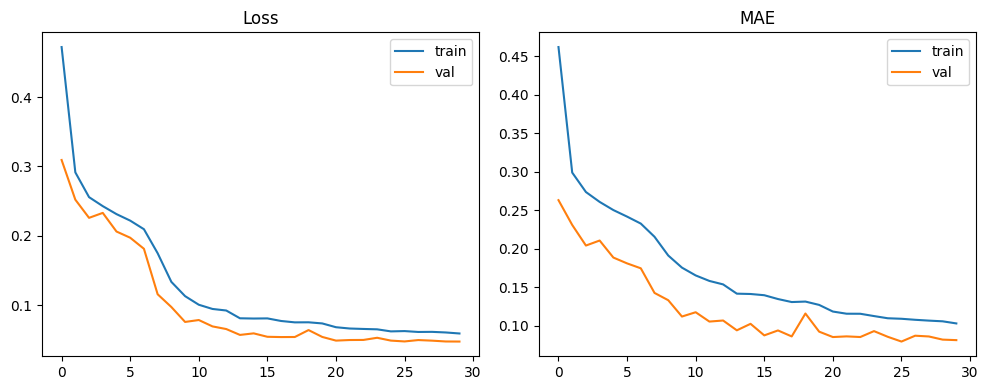

In [36]:

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="train")
plt.plot(history.history["val_mae"], label="val")
plt.title("MAE")
plt.legend()
plt.tight_layout()
plt.show()
